Mounted at /content/drive
Folders in dataset directory: ['Augmented Curry Leaf', 'Augmented Arjun Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Found 7724 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 3528s 4s/step - accuracy: 0.4121 - loss: 1.3019 - val_accuracy: 0.6950 - val_loss: 0.7404
Epoch 2/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 541s 560ms/step - accuracy: 0.7017 - loss: 0.7295 - val_accuracy: 0.8177 - val_loss: 0.4448
Epoch 3/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 527s 546ms/step - accuracy: 0.8698 - loss: 0.3698 - val_accuracy: 0.8224 - val_loss: 0.5251
Epoch 4/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 521s 540ms/step - accuracy: 0.9251 - loss: 0.2342 - val_accuracy: 0.9726 - val_loss: 0.0831
Epoch 5/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 518s 536ms/step - accuracy: 0.9537 - loss: 0.1493 - val_accuracy: 0.9637 - val_loss: 0.1258
Epoch 6/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 517s 535ms/step - accuracy: 0.9562 - loss: 0.1223 - val_accuracy: 0.9456 - val_loss: 0.1638
Epoch 7/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 554s 574ms/step - accuracy: 0.9527 - loss: 0.1379 - val_accuracy: 0.9591 - val_loss: 0.1157
Epoch 8/25
966/966 ━━━━━━━━━━━━━━━━━━━━ 517s 535ms/step - accuracy: 0.9660 - l

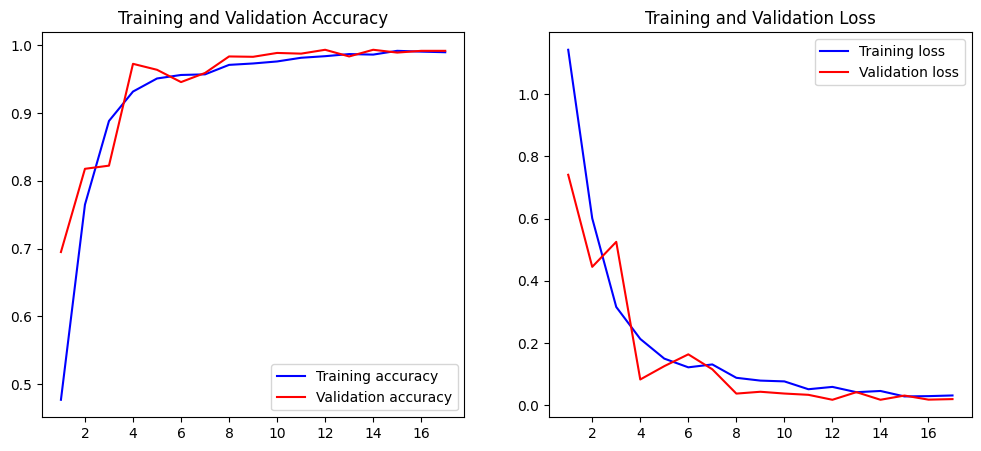

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os



data_dir = "/content/drive/MyDrive/augmented_dataset/new/Augmented Images (Version 02)"



#if the images are not loading properly then use this to check are they even present or not
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Dataset directory '{data_dir}' not found. Check your Google Drive path.")

print("Folders in dataset directory:", os.listdir(data_dir))









# rescale, rotate and cropping
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)





train_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)



# basic cnn model but effective with augmented data
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])



#high learning rate to increase the efficiency
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps=1000, decay_rate=0.9, staircase=True
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)


#training on fixed epoch and early stop if it overfits
history = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    callbacks=[early_stopping]
)



#saving the model
model_save_path = "/content/drive/MyDrive/Optimized_Leaf_Model.keras"
model.save(model_save_path)
print(f"Model saved at {model_save_path}")





# basic graph code to check accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [2]:
from google.colab import drive
drive.mount('/content/drive')


import tensorflow as tf

# loading saved model from drive
model_path = "/content/drive/MyDrive/Optimized_Leaf_Model.keras"
model = tf.keras.models.load_model(model_path)

print("✅ Model Loaded Successfully!")


Mounted at /content/drive
✅ Model Loaded Successfully!


In [35]:
import numpy as np
from tensorflow.keras.preprocessing import image

# image input here
image_path = "image6.jpg"

# use small size, but can increase it to 260x260 too
img = image.load_img(image_path, target_size=(150, 150))


img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Image Preprocessed Successfully!")



✅ Image Preprocessed Successfully!


In [36]:
class_labels = [
    "Augmented Arjun Leaf",
    "Augmented Curry Leaf",
    "Augmented Marsh Pennywort Leaf",
    "Augmented Mint Leaf",
    "Augmented Neem Leaf",
    "Augmented Rubble Leaf"
]


In [37]:
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions, axis=1)[0]

confidence = predictions[0][predicted_class_index] * 100



predicted_class_name = class_labels[predicted_class_index]

# result and values
print(predictions)
print(class_labels)
print(f"Predicted Class: {predicted_class_name} ({confidence:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[2.6617287e-17 3.5415633e-07 1.4586217e-20 1.7571566e-16 9.9999964e-01
  8.7741744e-13]]
['Augmented Arjun Leaf', 'Augmented Curry Leaf', 'Augmented Marsh Pennywort Leaf', 'Augmented Mint Leaf', 'Augmented Neem Leaf', 'Augmented Rubble Leaf']
Predicted Class: Augmented Neem Leaf (100.00% confidence)


In [10]:
# percentage accuracy

Curry Leaf: 0.00%
Arjun Leaf: 0.00%
Marsh Pennywort Leaf: 99.99%
Mint Leaf: 0.00%
Neem Leaf: 0.00%
Rubble Leaf: 0.01%
